In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                            confusion_matrix, classification_report, roc_curve, auc,
                            precision_recall_curve)
from sklearn.ensemble import IsolationForest
# from lightgbm import LGBMClassifier
# import lightgbm as lgb
import shap
from collections import defaultdict

# Set random seed for reproducibility
np.random.seed(42)

In [2]:
# Function to load and preprocess TCR data
def load_and_preprocess_tcr_data(file_path, target_column='Transition_Type'):
    """
    Load and preprocess TCR data from a CSV file.
    
    Parameters:
    -----------
    file_path : str
        Path to the CSV file containing TCR data
    target_column : str, default='Transition_Type'
        Name of the target column for classification
        
    Returns:
    --------
    X : pandas.DataFrame
        Features
    y : pandas.Series
        Target variable
    feature_names : list
        List of feature names
    metadata_columns : list
        List of metadata columns (non-features)
    """
    try:
        # Load the data
        print(f"Loading data from {file_path}...")
        df = pd.read_csv(file_path)
        
        # Print basic information about the dataset
        print(f"Dataset shape: {df.shape}")
        print(f"First few rows of the dataset:")
        print(df.head())
        
        # Identify metadata columns (non-features)
        metadata_columns = ["Patient", "Flare_Timepoint", "Remission_Timepoint", 
                            "Transition_Type", "Gene_Type", "Flare_File", "Remission_File"]
        
        # Extract feature columns
        feature_columns = [col for col in df.columns if col not in metadata_columns]
        
        # Replace any NaN values with 0
        X = df[feature_columns].fillna(0)
        
        # Check if target column exists
        if target_column not in df.columns:
            raise ValueError(f"Target column '{target_column}' not found in the dataset.")
        
        # For this classification, we want to predict transition types
        # Binary classification: is it a transition (F->R, R->F) or not (F->F, R->R)
        print(f"Unique values in {target_column}: {df[target_column].unique()}")
        
        # Create binary target: 1 for transitions (F->R, R->F), 0 for non-transitions (F->F, R->R)
        y = df[target_column].astype(str).str.strip().isin(["F->R", "R->F"]).astype(int)
        y.name = "is_transition"
        
        print(f"Target distribution:")
        print(y.value_counts())
        
        return X, y, feature_columns, metadata_columns, df
    
    except Exception as e:
        print(f"Error loading data: {e}")
        raise


Epoch [25/500], Loss: 0.6563
Epoch [50/500], Loss: 0.5523
Epoch [75/500], Loss: 0.4299
Epoch [100/500], Loss: 0.3025
Epoch [125/500], Loss: 0.1976
Epoch [150/500], Loss: 0.1271
Epoch [175/500], Loss: 0.0842
Epoch [200/500], Loss: 0.0590
Epoch [225/500], Loss: 0.0448
Epoch [250/500], Loss: 0.0364
Epoch [275/500], Loss: 0.0296
Epoch [300/500], Loss: 0.0245
Epoch [325/500], Loss: 0.0202
Epoch [350/500], Loss: 0.0171
Epoch [375/500], Loss: 0.0148
Epoch [400/500], Loss: 0.0131
Epoch [425/500], Loss: 0.0118
Epoch [450/500], Loss: 0.0107
Epoch [475/500], Loss: 0.0099
Epoch [500/500], Loss: 0.0090


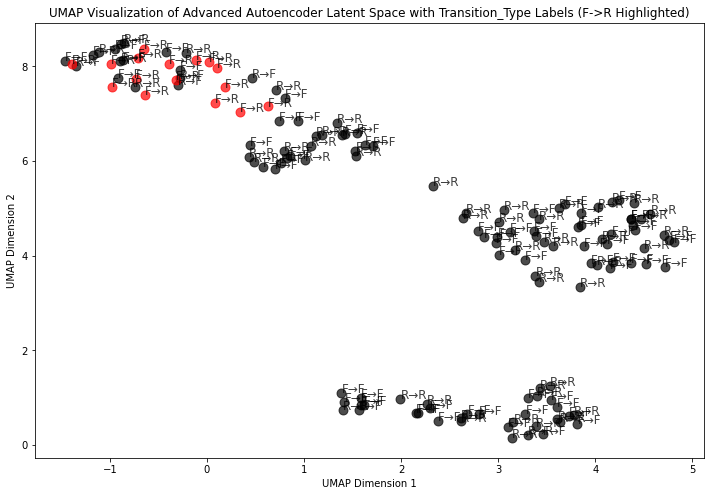

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import umap

# Load data
df = pd.read_csv("raw_freq_vdj_data.csv")

# Define feature columns
feature_columns = [col for col in df.columns if col not in ["Patient", "Flare_Timepoint", "Remission_Timepoint", "Transition_Type", "Gene_Type", "Flare_File", "Remission_File"]]
X = df[feature_columns].fillna(0)
X = StandardScaler().fit_transform(X)

# Apply Isolation Forest to detect outliers
iso_forest = IsolationForest(contamination=0.05)
outlier_predictions = iso_forest.fit_predict(X)

# Filter out the outliers
inlier_indices = np.where(outlier_predictions == 1)[0]
X_filtered = X[inlier_indices]
df_filtered = df.iloc[inlier_indices]

# Define Advanced Autoencoder class
class AdvancedAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(AdvancedAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim)
        )
    
    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed, latent

# Set parameters
input_dim = X_filtered.shape[1]
latent_dim = 10  # Increase latent dimensions for better representation

# Convert data to PyTorch tensors
X_tensor = torch.tensor(X_filtered, dtype=torch.float32)

autoencoder = AdvancedAutoencoder(input_dim, latent_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=0.0005)  # Reduced learning rate for better convergence

# Train Autoencoder with more epochs
epochs = 500
for epoch in range(epochs):
    optimizer.zero_grad()
    reconstructed, latent = autoencoder(X_tensor)
    loss = criterion(reconstructed, X_tensor)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 25 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

# Get latent representations
with torch.no_grad():
    _, latent_space = autoencoder(X_tensor)
    latent_space = latent_space.numpy()

# Apply UMAP for visualization
umap_embedding = umap.UMAP(n_neighbors=20, min_dist=0.05, n_components=2).fit_transform(latent_space)

# Plot UMAP embedding with highlighted F->R points
plt.figure(figsize=(12, 8))
for i, txt in enumerate(df_filtered["Transition_Type"].astype(str)):
    if txt == "F→R":
        color = 'red'
    else:
        color = 'black'
    plt.scatter(umap_embedding[i, 0], umap_embedding[i, 1], color=color, alpha=0.7, s=80)
    plt.annotate(txt, (umap_embedding[i, 0], umap_embedding[i, 1]), fontsize=12, alpha=0.75)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Visualization of Advanced Autoencoder Latent Space with Transition_Type Labels (F->R Highlighted)")
plt.show()


Epoch [50/1000], Loss: 0.6247
Epoch [100/1000], Loss: 0.4428
Epoch [150/1000], Loss: 0.2303
Epoch [200/1000], Loss: 0.1166
Epoch [250/1000], Loss: 0.0682
Epoch [300/1000], Loss: 0.0415
Epoch [350/1000], Loss: 0.0282
Epoch [400/1000], Loss: 0.0232
Epoch [450/1000], Loss: 0.0178
Epoch [500/1000], Loss: 0.0156
Epoch [550/1000], Loss: 0.0120
Epoch [600/1000], Loss: 0.0099
Epoch [650/1000], Loss: 0.0080
Epoch [700/1000], Loss: 0.0070
Epoch [750/1000], Loss: 0.0060
Epoch [800/1000], Loss: 0.0052
Epoch [850/1000], Loss: 0.0050
Epoch [900/1000], Loss: 0.0046
Epoch [950/1000], Loss: 0.0037
Epoch [1000/1000], Loss: 0.0036


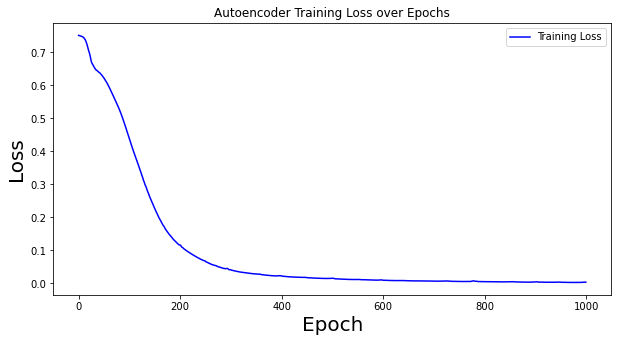

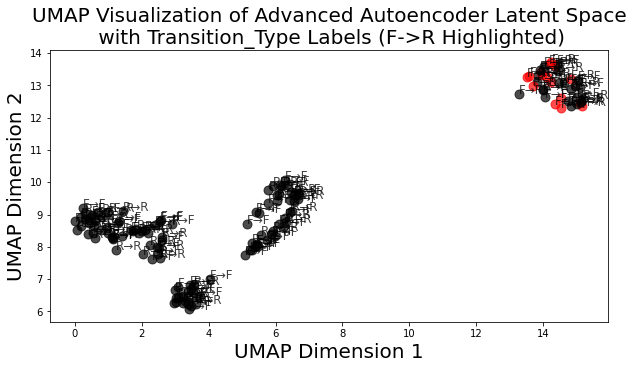

In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import umap

# Load data
df = pd.read_csv("raw_freq_vdj_data.csv")

# Define feature columns
feature_columns = [col for col in df.columns if col not in ["Patient", "Flare_Timepoint", "Remission_Timepoint", "Transition_Type", "Gene_Type", "Flare_File", "Remission_File"]]
X = df[feature_columns].fillna(0)
X = StandardScaler().fit_transform(X)

# Apply Isolation Forest to detect outliers
iso_forest = IsolationForest(contamination=0.05)
outlier_predictions = iso_forest.fit_predict(X)

# Filter out the outliers
inlier_indices = np.where(outlier_predictions == 1)[0]
X_filtered = X[inlier_indices]
df_filtered = df.iloc[inlier_indices]

# Define Advanced Autoencoder class
class AdvancedAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(AdvancedAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, input_dim)
        )
    
    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed, latent

# Set parameters
input_dim = X_filtered.shape[1]
latent_dim = 10  # Increase latent dimensions for better representation

# Convert data to PyTorch tensors
X_tensor = torch.tensor(X_filtered, dtype=torch.float32)

autoencoder = AdvancedAutoencoder(input_dim, latent_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=0.0003)  # Reduced learning rate for better convergence

# Train Autoencoder with more epochs
epochs = 1000
losses = []
for epoch in range(epochs):
    optimizer.zero_grad()
    reconstructed, latent = autoencoder(X_tensor)
    loss = criterion(reconstructed, X_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(range(epochs), losses, label='Training Loss', color='blue')
plt.xlabel("Epoch", fontsize=20)
plt.ylabel("Loss", fontsize=20)
plt.title("Autoencoder Training Loss over Epochs")
plt.legend()
plt.show()

# Get latent representations
with torch.no_grad():
    _, latent_space = autoencoder(X_tensor)
    latent_space = latent_space.numpy()

# Apply UMAP for visualization
umap_embedding = umap.UMAP(n_neighbors=20, min_dist=0.05, n_components=2).fit_transform(latent_space)

# Plot UMAP embedding with highlighted F->R points
plt.figure(figsize=(10, 5))
for i, txt in enumerate(df_filtered["Transition_Type"].astype(str)):
    if txt == "F→R":
        color = 'red'
    else:
        color = 'black'
    plt.scatter(umap_embedding[i, 0], umap_embedding[i, 1], color=color, alpha=0.7, s=80)
    plt.annotate(txt, (umap_embedding[i, 0], umap_embedding[i, 1]), fontsize=12, alpha=0.75)
plt.xlabel("UMAP Dimension 1", fontsize=20)
plt.ylabel("UMAP Dimension 2", fontsize=20)
plt.title("UMAP Visualization of Advanced Autoencoder Latent Space\n with Transition_Type Labels (F->R Highlighted)", fontsize=20)
plt.show()


In [6]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

# Load data
df = pd.read_csv("raw_freq_vdj_data.csv")

# Define feature columns
metadata_columns = ["Patient", "Flare_Timepoint", "Remission_Timepoint", "Transition_Type", "Gene_Type", "Flare_File", "Remission_File"]
feature_columns = [col for col in df.columns if col not in metadata_columns]

X = df[feature_columns].fillna(0)
X = StandardScaler().fit_transform(X)

# Apply Isolation Forest to remove outliers
iso_forest = IsolationForest(contamination=0.05, random_state=42)
outlier_predictions = iso_forest.fit_predict(X)
X_filtered = X[outlier_predictions == 1]
df_filtered = df.iloc[outlier_predictions == 1]

# ---- PCA Feature Importance ----
pca = PCA(n_components=10)
pca.fit(X_filtered)
explained_variance = np.abs(pca.components_).sum(axis=0)

pca_feature_importance = pd.DataFrame({"Feature": feature_columns, "Importance": explained_variance})
pca_feature_importance = pca_feature_importance.sort_values(by="Importance", ascending=False)

# ---- UMAP Feature Importance using SHAP ----
umap_model = umap.UMAP(n_neighbors=20, min_dist=0.05, n_components=2)
umap_embedding = umap_model.fit_transform(X_filtered)

# Suppose X_filtered is your feature matrix after outlier removal
num_features = X_filtered.shape[1]
required_evals = 2 * num_features + 1

explainer = shap.Explainer(
    umap_model.transform,
    X_filtered,
    max_evals=required_evals  # or pick a larger number to be safe
)

shap_values = explainer(X_filtered)


# explainer = shap.Explainer(umap_model.transform, X_filtered)
# shap_values = explainer(X_filtered)



PermutationExplainer explainer: 146it [12:00,  5.00s/it]                         


Epoch [50/500], Loss: 0.6428
Epoch [100/500], Loss: 0.4924
Epoch [150/500], Loss: 0.3348
Epoch [200/500], Loss: 0.2029
Epoch [250/500], Loss: 0.1275
Epoch [300/500], Loss: 0.0864
Epoch [350/500], Loss: 0.0614
Epoch [400/500], Loss: 0.0464
Epoch [450/500], Loss: 0.0376
Epoch [500/500], Loss: 0.0318


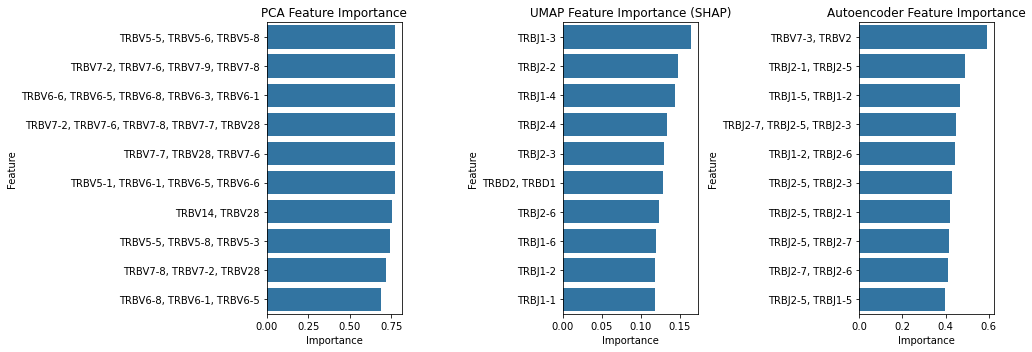

Feature importance analysis complete! Results saved as CSV files.


In [9]:
shap_importance = np.abs(shap_values.values).mean(axis=(0, 2))

# Now shap_importance is 1D, so this works:
shap_feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": shap_importance
})
shap_feature_importance = shap_feature_importance.sort_values(by="Importance", ascending=False)

# shap_importance = np.abs(shap_values.values).mean(axis=0)
# shap_feature_importance = pd.DataFrame({"Feature": feature_columns, "Importance": shap_importance})
# shap_feature_importance = shap_feature_importance.sort_values(by="Importance", ascending=False)

# ---- Autoencoder-based Feature Importance ----
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=10):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )
    
    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed, latent

# Convert data to PyTorch tensors
X_tensor = torch.tensor(X_filtered, dtype=torch.float32)

# Initialize and train autoencoder
input_dim = X_filtered.shape[1]
autoencoder = Autoencoder(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=0.0005)

# Training loop
epochs = 500
for epoch in range(epochs):
    optimizer.zero_grad()
    reconstructed, _ = autoencoder(X_tensor)
    loss = criterion(reconstructed, X_tensor)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

# Compute reconstruction error for feature importance
with torch.no_grad():
    reconstructed, _ = autoencoder(X_tensor)
    reconstruction_error = torch.mean((X_tensor - reconstructed) ** 2, axis=0).numpy()

autoencoder_feature_importance = pd.DataFrame({"Feature": feature_columns, "Importance": reconstruction_error})
autoencoder_feature_importance = autoencoder_feature_importance.sort_values(by="Importance", ascending=False)

# ---- Plot Feature Importance ----
plt.figure(figsize=(14, 5))
plt.subplot(1, 3, 1)
sns.barplot(x=pca_feature_importance["Importance"][:10], y=pca_feature_importance["Feature"][:10])
plt.title("PCA Feature Importance")
plt.xlabel("Importance")

plt.subplot(1, 3, 2)
sns.barplot(x=shap_feature_importance["Importance"][:10], y=shap_feature_importance["Feature"][:10])
plt.title("UMAP Feature Importance (SHAP)")
plt.xlabel("Importance")

plt.subplot(1, 3, 3)
sns.barplot(x=autoencoder_feature_importance["Importance"][:10], y=autoencoder_feature_importance["Feature"][:10])
plt.title("Autoencoder Feature Importance")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

# Save results
pca_feature_importance.to_csv("pca_feature_importance.csv", index=False)
shap_feature_importance.to_csv("shap_feature_importance.csv", index=False)
autoencoder_feature_importance.to_csv("autoencoder_feature_importance.csv", index=False)

print("Feature importance analysis complete! Results saved as CSV files.")


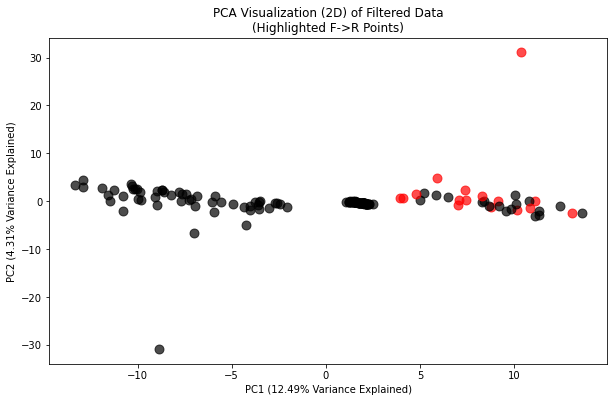

In [8]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# --------------------------------
# PCA with 2 components
# --------------------------------
pca = PCA(n_components=2, random_state=42)
pca_embedding = pca.fit_transform(X_filtered)

# Calculate explained variance ratio for each principal component
expl_var_1 = pca.explained_variance_ratio_[0] * 100
expl_var_2 = pca.explained_variance_ratio_[1] * 100

# --------------------------------
# PCA 2D SCATTER PLOT
# --------------------------------
plt.figure(figsize=(10, 6))
for i, txt in enumerate(df_filtered["Transition_Type"].astype(str)):
    if txt == "F->R" or txt == "F→R":  # handle both arrow types
        color = 'red'
    else:
        color = 'black'
        
    plt.scatter(
        pca_embedding[i, 0], 
        pca_embedding[i, 1],
        color=color, 
        alpha=0.7,
        s=80
    )

plt.xlabel(f"PC1 ({expl_var_1:.2f}% Variance Explained)")
plt.ylabel(f"PC2 ({expl_var_2:.2f}% Variance Explained)")
plt.title("PCA Visualization (2D) of Filtered Data\n(Highlighted F->R Points)")

plt.show()
